In [1]:
# Block 1: Load raw uncleaned dataset
import pandas as pd

df = pd.read_csv('Inventory_SupplyChain_Dataset_Raw.csv')
print("Raw shape:", df.shape)
print("\nMissing values found:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Raw shape: (1225, 15)

Missing values found:
Date                          0
Region                       20
Category                      0
Supplier                     31
Warehouse                     0
Order Status                  0
Units Sold                   62
Inventory Level               0
Transportation Cost          43
Order Accuracy                0
Lead Time (Days)             45
Backorder                     0
Cost of Goods Sold (COGS)    50
Average Inventory             0
Warehouse Capacity            0
dtype: int64

Duplicate rows: 25


In [2]:
# Block 2: Remove duplicates and fix missing values
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

# Fill missing numbers with median
df['Units Sold'] = df['Units Sold'].fillna(df['Units Sold'].median())
df['Lead Time (Days)'] = df['Lead Time (Days)'].fillna(df['Lead Time (Days)'].median())
df['Cost of Goods Sold (COGS)'] = df['Cost of Goods Sold (COGS)'].fillna(df['Cost of Goods Sold (COGS)'].median())
df['Transportation Cost'] = df['Transportation Cost'].fillna(df['Transportation Cost'].median())

# Fill missing text with Unknown
df['Supplier'] = df['Supplier'].fillna('Unknown')
df['Region'] = df['Region'].fillna('Unknown')

print("\nMissing values after cleaning:")
print(df.isnull().sum())
print("\nCleaned shape:", df.shape)

After removing duplicates: (1200, 15)

Missing values after cleaning:
Date                         0
Region                       0
Category                     0
Supplier                     0
Warehouse                    0
Order Status                 0
Units Sold                   0
Inventory Level              0
Transportation Cost          0
Order Accuracy               0
Lead Time (Days)             0
Backorder                    0
Cost of Goods Sold (COGS)    0
Average Inventory            0
Warehouse Capacity           0
dtype: int64

Cleaned shape: (1200, 15)


In [3]:
# Block 3: Validate data is clean
print("Total missing values remaining:", df.isnull().sum().sum())
print("Total duplicates remaining:", df.duplicated().sum())
print("Data is clean and ready for analysis.")

Total missing values remaining: 0
Total duplicates remaining: 0
Data is clean and ready for analysis.


In [4]:
# Block 4: Convert date column and extract year and month for time analysis
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')

print("Date column fixed:")
print(df[['Date', 'Year', 'Month', 'Month_Name']].head())

Date column fixed:
        Date  Year  Month Month_Name
0 2020-01-14  2020      1        Jan
1 2020-11-15  2020     11        Nov
2 2020-04-16  2020      4        Apr
3 2020-04-17  2020      4        Apr
4 2020-04-18  2020      4        Apr


In [5]:
# Block 5: Calculate key business KPIs for operational reporting
total_units = df['Units Sold'].sum()
avg_lead_time = df['Lead Time (Days)'].mean()
total_cogs = df['Cost of Goods Sold (COGS)'].sum()
avg_transport = df['Transportation Cost'].mean()
backorder_rate = df['Backorder'].mean() * 100
order_accuracy = df['Order Accuracy'].mean() * 100

print(f"Total Units Sold     : {total_units:,.0f}")
print(f"Average Lead Time    : {avg_lead_time:.1f} days")
print(f"Total COGS           : ${total_cogs:,.2f}")
print(f"Avg Transport Cost   : ${avg_transport:.2f}")
print(f"Backorder Rate       : {backorder_rate:.1f}%")
print(f"Order Accuracy Rate  : {order_accuracy:.1f}%")

Total Units Sold     : 637,978
Average Lead Time    : 15.7 days
Total COGS           : $70,959,414.11
Avg Transport Cost   : $7719.45
Backorder Rate       : 9.7%
Order Accuracy Rate  : 91.3%


Year
2020     54789.5
2021       761.0
2022    191320.0
2023    191385.0
2024    199722.5
Name: Units Sold, dtype: float64


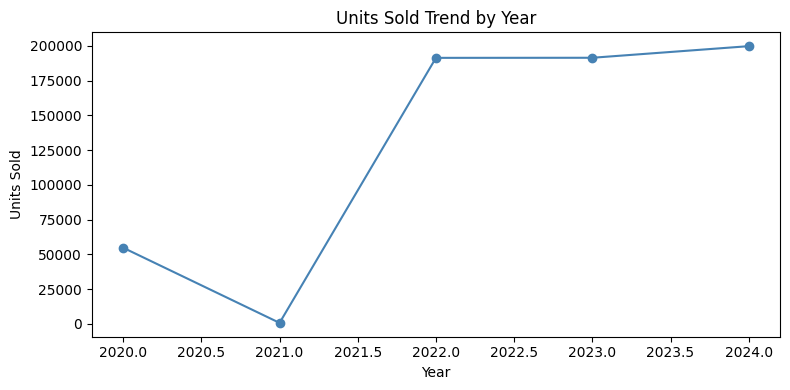

In [6]:
# Block 6: Analyze units sold trend over time for forecasting
import matplotlib.pyplot as plt

yearly_sales = df.groupby('Year')['Units Sold'].sum()
print(yearly_sales)

yearly_sales.plot(kind='line', marker='o', color='steelblue', figsize=(8,4))
plt.title('Units Sold Trend by Year')
plt.xlabel('Year')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.savefig('yearly_sales_trend.png')
plt.show()

Backorder Rate by Category (%):
Category
Accessories     8.92
Clothing        9.97
Electronics     7.32
Furniture      12.42
Name: Backorder, dtype: float64


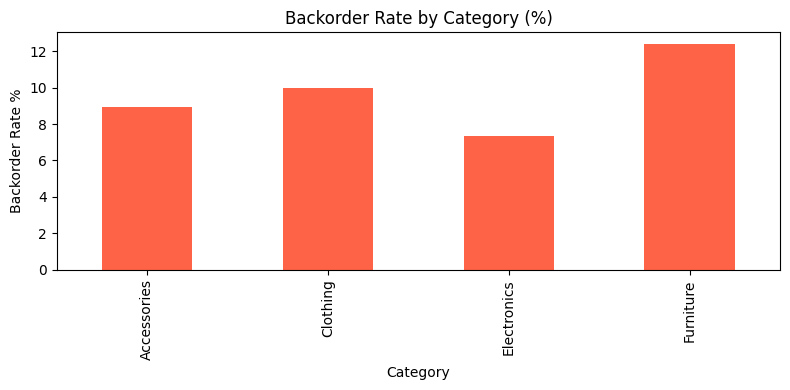

In [7]:
# Block 7: Analyze backorder rate and fulfillment performance by category
backorder_by_cat = df.groupby('Category')['Backorder'].mean() * 100
print("Backorder Rate by Category (%):")
print(backorder_by_cat.round(2))

backorder_by_cat.plot(kind='bar', color='tomato', figsize=(8,4))
plt.title('Backorder Rate by Category (%)')
plt.xlabel('Category')
plt.ylabel('Backorder Rate %')
plt.tight_layout()
plt.savefig('backorder_analysis.png')
plt.show()

Average Transportation Cost by Region:
Region
Unknown    8921.08
East       7894.93
North      7829.02
West       7770.58
South      7275.19
Name: Transportation Cost, dtype: float64


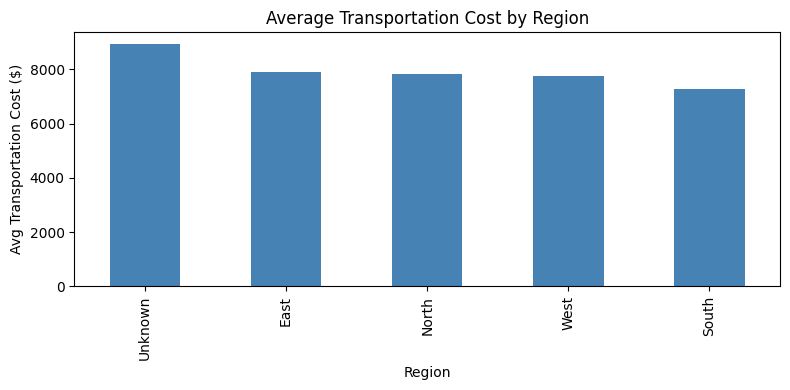

In [8]:
# Block 8: Analyze transportation cost by region to identify cost optimization opportunities
transport_by_region = df.groupby('Region')['Transportation Cost'].mean().sort_values(ascending=False)
print("Average Transportation Cost by Region:")
print(transport_by_region.round(2))

transport_by_region.plot(kind='bar', color='steelblue', figsize=(8,4))
plt.title('Average Transportation Cost by Region')
plt.xlabel('Region')
plt.ylabel('Avg Transportation Cost ($)')
plt.tight_layout()
plt.savefig('transport_cost_region.png')
plt.show()

In [9]:
# Block 9: Detect anomalies in units sold using z-score method
from scipy.stats import zscore

df['zscore'] = zscore(df['Units Sold'])
anomalies = df[df['zscore'].abs() > 2]

print(f"Total anomalies detected: {len(anomalies)}")
print("\nAnomaly records:")
print(anomalies[['Date', 'Category', 'Region', 'Units Sold', 'zscore']].head(10))

Total anomalies detected: 0

Anomaly records:
Empty DataFrame
Columns: [Date, Category, Region, Units Sold, zscore]
Index: []


Monthly Sales with 3-Month Rolling Forecast:
    Year  Month  Units Sold      Forecast
33  2024      3     13571.5  15871.333333
34  2024      4     16643.0  15292.166667
35  2024      5     17440.5  15885.000000
36  2024      6     15378.0  16487.166667
37  2024      7     16876.5  16565.000000
38  2024      8     17541.5  16598.666667
39  2024      9     16956.5  17124.833333
40  2024     10     19407.0  17968.333333
41  2024     11     16438.5  17600.666667
42  2024     12     15427.0  17090.833333


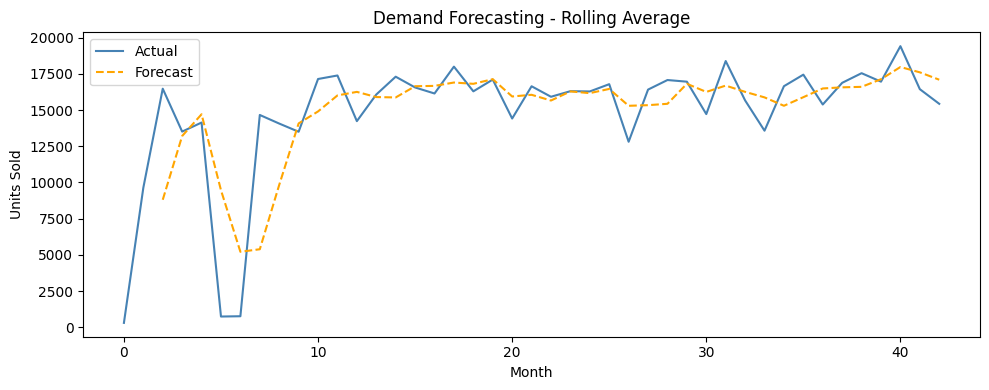

In [10]:
# Block 10: Build rolling average forecast to predict future demand trends
monthly_sales = df.groupby(['Year', 'Month'])['Units Sold'].sum().reset_index()
monthly_sales['Forecast'] = monthly_sales['Units Sold'].rolling(window=3).mean()

print("Monthly Sales with 3-Month Rolling Forecast:")
print(monthly_sales.tail(10))

plt.figure(figsize=(10,4))
plt.plot(monthly_sales['Units Sold'].values, label='Actual', color='steelblue')
plt.plot(monthly_sales['Forecast'].values, label='Forecast', color='orange', linestyle='--')
plt.title('Demand Forecasting - Rolling Average')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.savefig('demand_forecast.png')
plt.show()

In [11]:
# Block 11: Use PySpark for large scale data transformation and aggregation
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName('SupplyChainAnalytics').getOrCreate()

spark_df = spark.createDataFrame(df)

spark_df.createOrReplaceTempView('supply_chain')

result = spark.sql("""
    SELECT Region, Category,
           SUM(`Units Sold`) as Total_Units,
           AVG(`Lead Time (Days)`) as Avg_Lead_Time,
           AVG(`Transportation Cost`) as Avg_Transport_Cost
    FROM supply_chain
    GROUP BY Region, Category
    ORDER BY Total_Units DESC
""")

result.show()

+-------+-----------+-----------+------------------+------------------+
| Region|   Category|Total_Units|     Avg_Lead_Time|Avg_Transport_Cost|
+-------+-----------+-----------+------------------+------------------+
|   West|Electronics|    50075.0|  16.0989010989011| 8137.171754850548|
|  South|   Clothing|    45543.0|15.423529411764706|6855.2872085894105|
|  North|   Clothing|    44680.5|15.355263157894736| 7535.911708721052|
|  North|Electronics|    44089.0|15.535714285714286| 7505.413558359524|
|  North|  Furniture|    42501.5|15.819277108433734|  8312.98168832048|
|   West|  Furniture|    41918.0|15.426829268292684| 8064.221765093903|
|   West|   Clothing|    40536.0|15.789473684210526| 7539.227990715791|
|   East|  Furniture|    38604.0|15.887323943661972| 7408.296942318311|
|   East|Accessories|    37317.5|15.955882352941176| 7596.729641461766|
|   East|Electronics|    36835.0|15.376811594202898| 8482.155739073913|
|   East|   Clothing|    36510.0| 14.82857142857143| 8099.345860